[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giuliofranzese/Cajal/blob/main/tende/TENDE_notebook_colab.ipynb)

# TENDE: Transfer Entropy Neural Data Estimator

Interactive notebook for estimating directed information flow with neural networks.

**Topics covered:**
- Transfer entropy as conditional MI
- Time series embedding and lag selection
- Neural conditional density estimation
- TENDE: directed information estimation
- Application to neural/biological time series

## 0. Setup: upload folder and install dependencies

In [1]:
# upload TENDE_src_ckpt_data.zip, you can find it in https://github.com/giuliofranzese/Cajal/tree/main/tende
from google.colab import files
uploaded = files.upload()

Saving TENDE_src_ckpt_data.zip to TENDE_src_ckpt_data.zip


In [2]:
!unzip -q TENDE_src_ckpt_data.zip

In [3]:
%cd TENDE_src_ckpt_data
%ls

/content/TENDE_src_ckpt_data
lightning_logs/  multiseeds.py  src/


In [25]:
# install pytorch_lightning
import subprocess
import sys
subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            "pytorch_lightning",
        ],
        check=True,
    )

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'pytorch_lightning'], returncode=0)

In [26]:
import os
sys.path.insert(0, os.path.abspath("src"))

from scripts.helper import *
from libs.tende import *
from libs.util import get_samples

In [27]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pytorch_lightning import seed_everything

## 1. Coupled Ornstein-Uhlenbeck Process

We simulate a system where $Y \to X$ (unidirectional coupling) and verify that TENDE recovers the correct direction.

### 1.1 Data visulization

In [28]:
seed = 42
seed_everything(seed)
# torch.manual_seed(seed)
# np.random.seed(seed)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

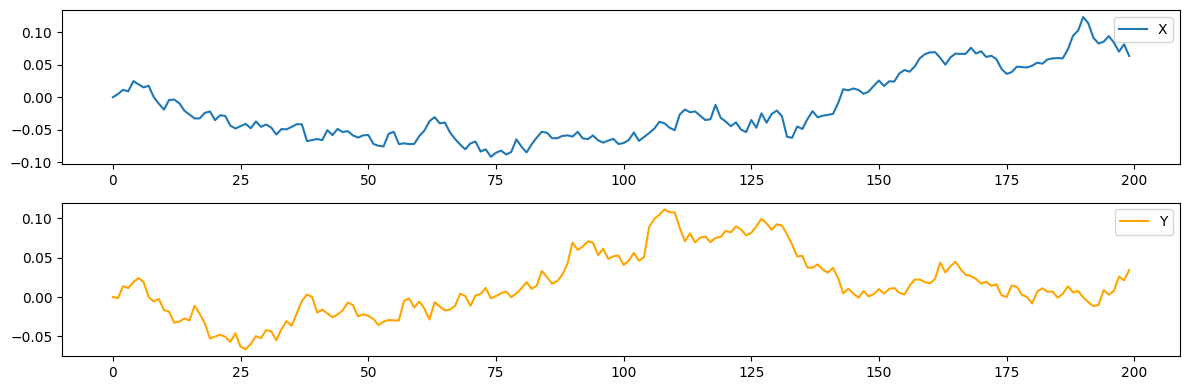

In [29]:
def simulate_coupled_ou(T=2000, coupling_yx=0.5, coupling_xy=0.0, dt=0.01, noise=0.1):
    """Simulate coupled OU processes."""
    X = np.zeros(T)
    Y = np.zeros(T)
    for t in range(1, T):
        X[t] = X[t-1] + dt*(-X[t-1] + coupling_yx*Y[t-1]) + noise*np.sqrt(dt)*np.random.randn()
        Y[t] = Y[t-1] + dt*(-Y[t-1] + coupling_xy*X[t-1]) + noise*np.sqrt(dt)*np.random.randn()
    return X, Y

X, Y = simulate_coupled_ou(coupling_yx=0.5, coupling_xy=0.0)

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
axes[0].plot(X[:200], label='X')
axes[1].plot(Y[:200], label='Y', color='orange')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

### 1.2. Time Series Embedding and Transfer Entropy Estimation

estimate TE_{Y->X} and TE_{X->Y}

verify: TE_{X->Y} ≈ 0, TE_{Y->X} > 0

In [30]:
T = X.shape[0]
config = get_default_config() #importing the default configuration
config.Train_Size = T - 100 #here we are training with all the data but 100 last time points
config.Test_Size = T - config.Train_Size
config.use_ema = True
config.importance_sampling = True
config.lr = 1e-3
config.bs = 128

#### Transfer entropy : $X \to Y = 0$

In [31]:
#this is how the time series is formatted as required for TENDE
#the function used below follows the generic structure get_data_loader(fro, to, lf, lt, config)
# fro, to: time series from (source), time series to (target) respectively
# lf, lt: lag source, lag target respectively

X, Y = X.reshape(-1, 1), Y.reshape(-1, 1)
train_loader, test_loader, var_list = get_data_loader(X, Y, 1, 1, config)

True


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [32]:
default_root_dir = f"lightning_logs/seed{seed}/TE_X2Y"
print('epochs: ', config.max_epochs)

#this is how the model is instantiated
try:
    tende = TENDE.load_from_checkpoint(f"{default_root_dir}/checkpoints/epoch={config.max_epochs-1}.ckpt", weights_only = False,
                                       args = config, var_list = var_list)
    tende.eval()

    tende.test_samples = get_samples(test_loader,device="cuda"if tende.args.accelerator == "gpu" else "cpu")

    print('Model loaded from checkpoint.')

except:
    tende = TENDE(args = config, var_list = var_list)

    #training the model
    tende.fit(train_loader, test_loader, default_root_dir=default_root_dir)

    print('Model trained and saved to checkpoint.')

epochs:  250


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Model loaded from checkpoint.


In [33]:
# I am leaving this commented in case you need to use it, it is already implemented in ./src/scripts/helper.py as get_data_formatted
# def embed_series(x, history_len, tau=1):
#     """Embed time series into (history, future) pairs."""
#     history = np.stack([x[t:t+history_len] for t in range(len(x)-history_len-tau+1)])
#     future = x[history_len+tau-1:history_len+tau-1+len(history)]
#     return history, future

# k = 5  # history length
# tau = 1  # prediction lag
# x_hist, x_fut = embed_series(X, k, tau)
# y_hist, _ = embed_series(Y, k, tau)
# print(f"x_hist shape: {x_hist.shape}, x_fut shape: {x_fut.shape}")

In [34]:
#using the first estimator that is guaranteed to have non-negative estimates

seed_everything(seed)
tende.compute_te()[0]

INFO:lightning_fabric.utilities.seed:Seed set to 42


np.float64(0.020491689257323743)

#### Transfer entropy : $Y \to X > 0$

In [35]:
# #to go in the other direction the only thing that is required is to swap the roles of X and Y
train_loader, test_loader, var_list = get_data_loader(Y, X, 1, 1, config)

True


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [36]:
default_root_dir = f"lightning_logs/seed{seed}/TE_Y2X"
print('epochs: ', config.max_epochs)

#this is how the model is instantiated
try:
    tende = TENDE.load_from_checkpoint(f"{default_root_dir}/checkpoints/epoch={config.max_epochs-1}.ckpt", weights_only = False,
                                       args = config, var_list = var_list)
    tende.eval()

    tende.test_samples = get_samples(test_loader,device="cuda"if tende.args.accelerator == "gpu" else "cpu")

    print('Model loaded from checkpoint.')

except:
    tende = TENDE(args = config, var_list = var_list)

    #training the model
    tende.fit(train_loader, test_loader, default_root_dir=default_root_dir)

    print('Model trained and saved to checkpoint.')

epochs:  250


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Model loaded from checkpoint.


In [37]:
seed_everything(seed)
tende.compute_te()[0]

INFO:lightning_fabric.utilities.seed:Seed set to 42


np.float64(0.05522510036826134)

## 2. Application: Neural Population Data

Lag Sensitivity Analysis

### 2.1 Data visulization

In [38]:
seed = 142
seed_everything(seed)

INFO:lightning_fabric.utilities.seed:Seed set to 142


142

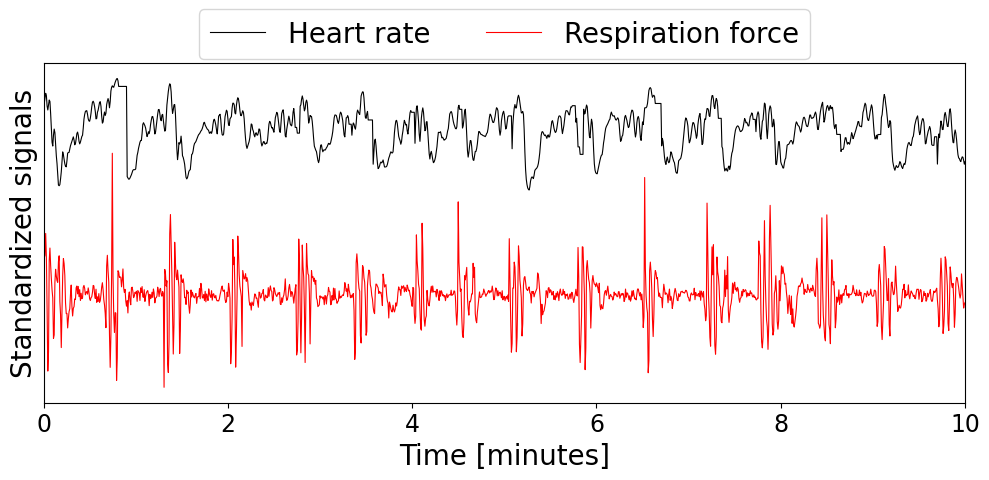

In [39]:
data = np.load("./src/application_data.npy")

heart_rate = data[:, 0]
respiration_force = data[:, 1]

# Standardize signals (z-score normalization)
heart_rate_std = (heart_rate - np.mean(heart_rate)) / np.std(heart_rate)
respiration_force_std = (respiration_force - np.mean(respiration_force)) / np.std(respiration_force)

# Shift respiration force down to avoid overlap
# You can adjust this offset value to control the separation
offset = np.max(heart_rate_std) - np.min(respiration_force_std) + 1
respiration_force_shifted = respiration_force_std - offset

# Create time axis
n_samples = len(heart_rate)
time_minutes = np.linspace(0, 10, n_samples)

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Plot both signals
ax.plot(time_minutes, heart_rate_std, 'k-', linewidth=0.8, label='Heart rate')
ax.plot(time_minutes, respiration_force_shifted, 'r-', linewidth=0.8, label='Respiration force')

# Labels and formatting
ax.set_xlabel('Time [minutes]', fontsize=20)
ax.set_ylabel('Standardized signals', fontsize=20)
ax.set_xlim(0, 10)
ax.tick_params(axis='both', labelsize=17) #changed

# Remove y-axis ticks
ax.set_yticks([])

# Remove grid
ax.grid(False)

# Legend at top
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.20), ncol=2, frameon=True, fontsize=20)

plt.tight_layout()

### 2.2. Time Series Embedding and Transfer Entropy Estimation


In [40]:
#getting the data as column vectors
heart, breath = data[:, 0].reshape(-1, 1), data[:, 1].reshape(-1, 1)

In [41]:
config = get_default_config()
config.Train_Size = data.shape[0] - 100
config.Test_Size = 100
config.mc_iter = 1000
config.use_ema = True
config.importance_sampling = True


def obtain_te_application(fro, to, lag, note=""):
    global config
    train_loader, test_loader, var_list = get_data_loader(fro, to, 2, lag, config)

    dim = sum(list(var_list.values()))

    if dim <= 5:
        config.max_epochs = 300
        config.lr = 1e-3
        config.bs = 128
    elif dim > 5:
        config.max_epochs = 500
        config.lr = 2e-3
        config.bs = 256

    # tende = TENDE(config, var_list = var_list)
    # tende.fit(train_loader)


    default_root_dir = f"lightning_logs/seed{seed}/{note}/{lag}"
    print('epochs: ', config.max_epochs)

    #this is how the model is instantiated
    try:
        tende = TENDE.load_from_checkpoint(f"{default_root_dir}/checkpoints/epoch={config.max_epochs-1}.ckpt", weights_only = False,
                                        args = config, var_list = var_list)
        tende.eval()

        tende.test_samples = get_samples(train_loader,device="cuda"if tende.args.accelerator == "gpu" else "cpu")

        print('Model loaded from checkpoint.')

    except:
        tende = TENDE(args = config, var_list = var_list)

        #training the model
        tende.fit(train_loader, default_root_dir=default_root_dir)

        print('Model trained and saved to checkpoint.')

    seed_everything(seed)
    te, _ = tende.compute_te()

    return te

#### Transfer entropy : breath to heart

In [42]:
te_breath_to_heart = np.array([obtain_te_application(breath, heart, lag=lag, note="breath2heart") for lag in range(2, 12, 2)])

True
epochs:  300


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:lightning_fabric.utilities.seed:See

Model loaded from checkpoint.
True
epochs:  500


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:lightning_fabric.utilities.seed:See

Model loaded from checkpoint.
True
epochs:  500


...

Model loaded from checkpoint.
True
epochs:  500


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:lightning_fabric.utilities.seed:See

Model loaded from checkpoint.
True
epochs:  500


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:lightning_fabric.utilities.seed:See

Model loaded from checkpoint.


#### Transfer entropy : heart to breath

In [43]:
te_heart_to_breath = np.array([obtain_te_application(heart, breath, lag=lag, note="heart2breath") for lag in range(2, 12, 2)])

True
epochs:  300


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:lightning_fabric.utilities.seed:See

Model loaded from checkpoint.
True
epochs:  500


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:lightning_fabric.utilities.seed:See

Model loaded from checkpoint.
True
epochs:  500


...

Model loaded from checkpoint.
True
epochs:  500


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:lightning_fabric.utilities.seed:See

Model loaded from checkpoint.
True
epochs:  500


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:lightning_fabric.utilities.seed:See

Model loaded from checkpoint.


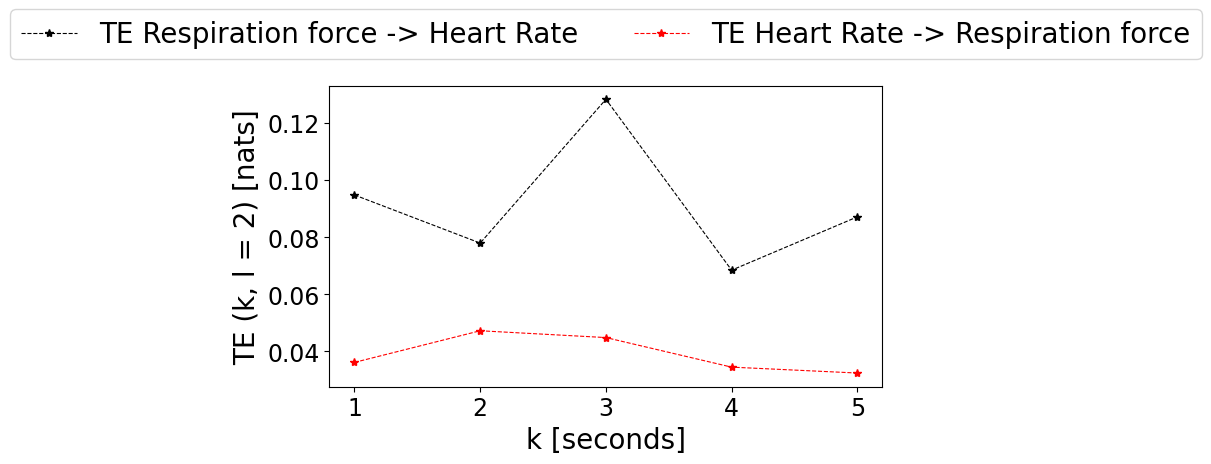

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Plot both signals
ax.plot(np.arange(1, 6), te_breath_to_heart, 'k*--', linewidth=0.8, label='TE Respiration force -> Heart Rate')
ax.plot(np.arange(1, 6), te_heart_to_breath, 'r*--', linewidth=0.8, label='TE Heart Rate -> Respiration force')

# Labels and formatting
ax.set_xlabel('k [seconds]', fontsize=20)
ax.set_ylabel(r'TE (k, l = 2) [nats]', fontsize=20)
ax.tick_params(axis='both', labelsize=17)


# Remove grid
ax.grid(False)

# Legend at top
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.30), ncol=2, frameon=True, fontsize=20)

plt.tight_layout()